In [1]:
import pandas as pd
import geopandas as gpd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from geodatasets import get_path
from pathlib import Path
import pyarrow.parquet as pypq
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import textwrap 
import duckdb
import math
from sklearn.cluster import HDBSCAN
import numpy as np
from geopy.distance import geodesic
# ---------------------------------------------------------
# 📂 GLOBAL PATHS - DO NOT CHANGE THESE
# ---------------------------------------------------------
BASE_PATH = Path("/data/shared/OpenAlex/processed-snapshots")
PARQUET_PATH = BASE_PATH / "parquet-files" / "may-2025"
CSV_PATH = BASE_PATH / "csv-files" / "may-2025"

print(f"✅ Data Directories Set:\n  - Parquet: {PARQUET_PATH}\n  - CSV: {CSV_PATH}")

✅ Data Directories Set:
  - Parquet: /data/shared/OpenAlex/processed-snapshots/parquet-files/may-2025
  - CSV: /data/shared/OpenAlex/processed-snapshots/csv-files/may-2025


In [2]:
# Connect to duckdb
con = duckdb.connect()
# Limit memory usage
con.execute("SET memory_limit = '6GB'")
# Disable progress bars to avoid exceeding message limit
con.execute("SET enable_progress_bar = false")
con.execute("SET enable_progress_bar_print = false")

In [3]:
# Table paths
works_path = PARQUET_PATH / "works"
topics_path = PARQUET_PATH / "works_topics"
works_references_works_path = PARQUET_PATH / "works_referenced_works"
authorships_path = PARQUET_PATH / "works_authorships"
primary_location_path = PARQUET_PATH / "works_primary_location"
work_grants_path = PARQUET_PATH / "works_grants"
# csv paths
institutions_file = CSV_PATH / "institutions.csv.gz"
institutions_geo_file = CSV_PATH / "institutions_geo.csv.gz"
funders_file = CSV_PATH / "funders.csv.gz"
sources_file = CSV_PATH / "sources.csv.gz"

In [4]:
machine_learning_topics = {
    12676: "Machine Learning and ELM",
    12072: "Machine Learning and Algorithms",
    12535: "Machine Learning and Data Classification",
    13702: "Machine Learning in Healthcare",
    11689: "Adversarial Robustness in Machine Learning"
}

## Do machine learning topics have a global spread through physical proximity or institutional networks?
We have refined our initial question on how topics spread globally to focus on how Machine Learning spreads, either by physical proximity or through institutional networks. With the ease that the internet provides to share information around the globe instantly, does the research spread from one research hub to its neighboring hubs, or does it spread through networks such as Stanford to MIT to Oxford?

### Creating DuckDB tables
To limit the number of works, and to keep memory usage low, 
1) the works_topics table is created with the following machine learning topics: 
* 12676: "Machine Learning and ELM"
* 12072: "Machine Learning and Algorithms"
* 12535: "Machine Learning and Data Classification"
* 13702: "Machine Learning in Healthcare"
* 11689: "Adversarial Robustness in Machine Learning"

Since the works_topics table also contains the work_ids and publication_year, the works in this table are limited to those published between 2010 and 2019 to further reduce the size of the table to a single decade of works.

2) The works table was created by selecting the works with work_ids from the works_topics table. To reduce the number of tables and joins needed, the institution_id of the first author for each work is taken from the authorship parquet file and added as a column in the works table. The works are further filtered to works that have been cited more than 50 times and the institution_id must not be null.

3) The institutions_geo table is created by selecting the institution_ids from the works table. The institutions file has been left out entirely since the institutions geo file contains all the relevant columns we need.

In [5]:
# Create the topics tables within the topics of Machine Learning with works published between 2010 and 2020
con.execute(f"""
    CREATE OR REPLACE TABLE works_topics AS 
    SELECT 
        work_id, 
        topic_id,  
        subfield_id
    FROM read_parquet('{topics_path}/**/*.parquet')
    WHERE topic_id in (12676, 12072, 12535, 13702, 11689) AND publication_year >= 2010 AND publication_year <=2019
""")
print("✅ Created topics")

# Create the works table and include the institution_id from the authorships table
con.execute(f"""
    CREATE OR REPLACE TABLE works AS 
    WITH filtered_ids AS (
        SELECT DISTINCT work_id FROM works_topics
    ),
    primary_authorship AS (
        SELECT work_id, institution_id
        FROM read_parquet('{authorships_path}/**/*.parquet')
        WHERE author_position = 'first'
    )
    SELECT 
        w.work_id, 
        w.publication_year, 
        w.cited_by_count,
        a.institution_id
    FROM read_parquet('{works_path}/**/*.parquet') w
    INNER JOIN filtered_ids f ON w.work_id = f.work_id
    LEFT JOIN primary_authorship a ON w.work_id = a.work_id
    WHERE w.cited_by_count > 50 AND a.institution_id IS NOT NULL
""")
print("✅ Created works with institution_id")

# Create the institutions_geo table
con.execute(f"""
    CREATE OR REPLACE TABLE institutions_geo AS 
    SELECT 
        i.institution_id, 
        i.geonames_city_id, 
        i.city,
        i.country_code, 
        i.latitude, 
        i.longitude 
    FROM read_csv_auto('{institutions_geo_file}') i
    JOIN (SELECT DISTINCT institution_id FROM works) w ON w.institution_id = i.institution_id
""")
print("✅ Created institutions_geo")

✅ Created topics
✅ Created works with institution_id
✅ Created institutions_geo


### Finding Research hubs
To find the research hubs, we first created a dataframe of the institutions and convert their latitude and longitude into radians since we are looking at points on a sphere. 

After calculating k-means and the silhouette score, the optimal number of clusters was determined to be 3, which represents entire continents. This does not help us track the spread of topics since we want smaller, precise clusters. K-means is also grouping institutions that might not be considered part of a research hub since k-means includes noise points.

In [6]:
# Getting the latitude and longitude for the institutions and convert to radians
query = f"""
        SELECT institution_id, city, latitude, longitude 
        FROM institutions_geo
    """
institutions = con.execute(query).df()
institutions['rlatitude'] = institutions['latitude'] * (math.pi / 180)
institutions['rlongitude'] = institutions['longitude'] * (math.pi / 180)

institution_radians = institutions[['rlatitude', 'rlongitude']].values

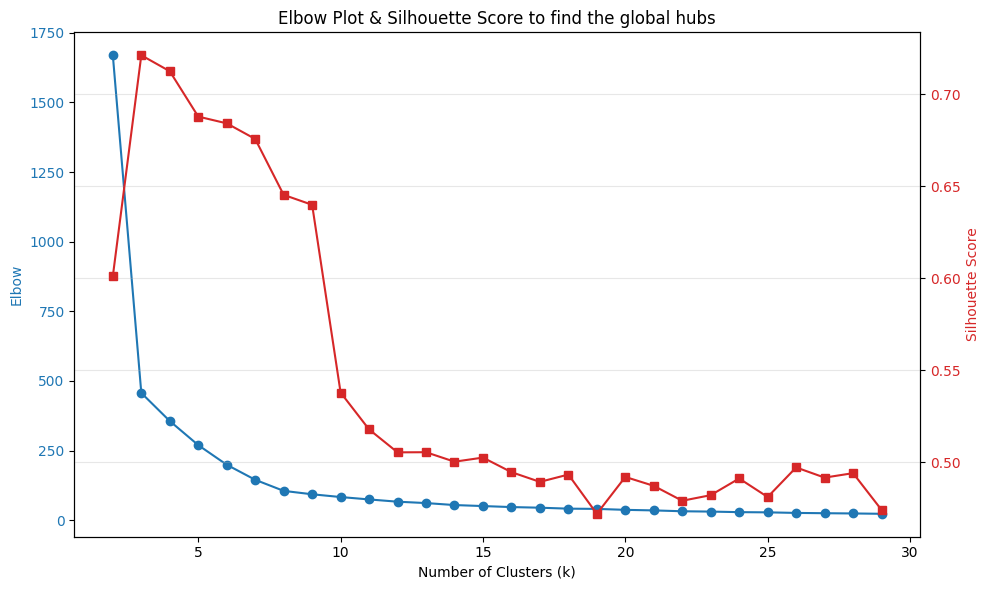

In [7]:
K_range = range(2, 30)
inertia = []
s_scores = []

# Looping through to get the elbow and silhouette
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(institution_radians)
    
    inertia.append(kmeans.inertia_)
    s_scores.append(silhouette_score(institution_radians, labels))

# Plotting the data
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Elbow', color=color)
ax1.plot(K_range, inertia, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx() 
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(K_range, s_scores, marker='s', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Elbow Plot & Silhouette Score to find the global hubs')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

After running DBSCAN, we are given 76 research hubs, which will be much more useful to track the spread of topics. There are 818 institutions that do not belong to any research hubs, but may still be researching and publishing works on machine learning topics.

The research clusters are named by the city with the most institutions within the research cluster. 

The centroids for each research hub a calculated by taking the mean latitude and longitude of all the institutions in the cluster.

In [8]:
# Run DBSCAN
model = HDBSCAN(min_cluster_size=10, metric='haversine', cluster_selection_method='eom', copy=True)
institutions['dbscan_cluster'] = model.fit_predict(institution_radians)

# Find the hub names
hub_names = institutions[institutions['dbscan_cluster'] != -1].groupby('dbscan_cluster')['city'].agg(lambda x: x.value_counts().index[0])

num_hubs = len(institutions[institutions['dbscan_cluster'] != -1]['dbscan_cluster'].unique())
noise_count = len(institutions[institutions['dbscan_cluster'] == -1])
print(f"Found {num_hubs} dense research hubs and {noise_count} noise institutions")

# Find the centroids
hub_centroids = institutions.groupby('dbscan_cluster')[['latitude', 'longitude']].mean().reset_index()

Found 76 dense research hubs and 818 noise institutions


## Counting number of works per research hub by year
1) Count how many works each institution published each year for a topic.
2) Merge the results with the research hub data and group by research hub. 
3) Save each year and its counts in a dictionary to easily access later.

In [9]:
topic_id = 13702
all_years_data = {}

for year in range(2010, 2020):
    yearly_query = f"""
        SELECT w.institution_id, count(w.work_id) as num_works
        FROM works_topics t
        JOIN works w ON w.work_id = t.work_id
        WHERE w.publication_year = {year} AND t.topic_id = {topic_id}
        GROUP BY w.institution_id
    """
    
    # Get SQL results
    results = con.execute(yearly_query).df()
    # Merge with cluster map
    merged = results.merge(institutions[['institution_id', 'dbscan_cluster']], on='institution_id')
    # Sum by Hub
    counts = merged.groupby('dbscan_cluster')['num_works'].sum().reset_index()
    counts['year'] = year
    all_years_data[year] = counts

## Finding the weighted center for the topic for each year
To see how the topic spreads over the years, we use Spatio-Temporal Centroid Tracking to calculate the weighted center of all the research hubs based on the number of works each hub published that year. We loop through the entire decade and calculate the distance the weighted center moved from the previous year.

In [10]:
def calculate_hub_topic_center(year_counts_df, hub_centroids):
    # Merge the hub counts with their geographic centers
    geo_data = year_counts_df.merge(hub_centroids, on='dbscan_cluster')
    # Calculate the weighted average latitude and longitude
    weights = geo_data['num_works']
    avg_lat = np.average(geo_data['latitude'], weights=weights)
    avg_lon = np.average(geo_data['longitude'], weights=weights)
    return avg_lat, avg_lon

yearly_centers_data = []
previous_year = (0,0)
for year in range(2010, 2020):
    year_center = calculate_hub_topic_center(all_years_data[year], hub_centroids)
    year_row = {}
    year_row['year'] = year
    year_row['latitude'] = year_center[0]
    year_row['longitude'] = year_center[1]
    if year != 2010:
        year_row['distance'] = geodesic(year_center, previous_year).km
    else:
        year_row['distance'] = 0
    previous_year = year_center
    yearly_centers_data.append(year_row)

df_yearly_centers = pd.DataFrame(yearly_centers_data)

display(df_yearly_centers)

,year,latitude,longitude,distance
0,2010,24.089180,24.094691,0.000000
1,2011,40.790423,-39.369466,6111.250947
2,2012,38.584488,-34.986580,448.620424
3,2013,39.825056,-22.656457,1073.018635
4,2014,36.959104,-14.287178,796.943493
5,2015,39.225519,-28.239076,1248.125036
6,2016,36.621322,-16.349103,1083.706023
7,2017,38.738302,-11.528127,485.765227
8,2018,37.521290,-12.426944,156.391135
9,2019,38.535650,-6.266751,552.334040


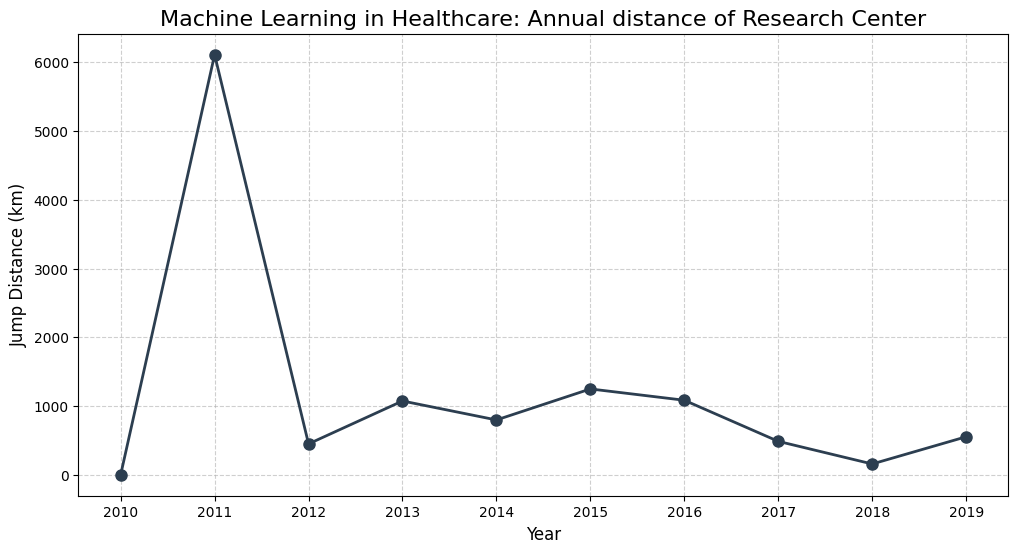

In [11]:
plt.figure(figsize=(12, 6))

# Plot the distance jumps
plt.plot(df_yearly_centers['year'], df_yearly_centers['distance'], 
         marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=8)

# Professional formatting for your report
plt.title(f'{machine_learning_topics[topic_id]}: Annual distance of Research Center', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Jump Distance (km)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(df_yearly_centers['year'])

plt.savefig(f'{topic_id}_yearly_distance.png', dpi=300, bbox_inches='tight')
plt.show()

Note: You can change the topic ID in cell 9 using the topic_ids in cell 4 to create graphs for all the machine learning topics